# **3.7 A Concise Implementation of Softmax Regression**
In [Section 3.3](./linear_regression.ipynb#33), we saw that the high-level APIs provided by deep learning frameworks make it easier to implement linear regression. Similarly, these high-level APIs also make it easier to implement softmax regression models. As in [Section 3.6](./implementing_softmax_regression_from_scratch.ipynb#36), this section continues to use the Fashion-MNIST dataset and maintains a batch size of 256.

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [7]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, root='../../data')

## **3.7.1 Initialize Model Parameters**
As discussed in [Section 3.4](./softmax_regression.ipynb#34), the output layer of softmax regression is a fully connected layer. Therefore, to implement our model, we simply need to add a fully connected layer with 10 outputs to `Sequential`. Again, `Sequential` is not strictly necessary here, but it serves as the foundation for implementing deep models. We continue to randomly initialize the weights with a mean of 0 and a standard deviation of 0.01.

In [2]:
# PyTorch does not implicitly adjust the shape of the input. Therefore,
# we define a `flatten` layer before the linear layer to adjust the shape of the network input.
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

## **3.7.2 A Fresh Look at the Implementation of Softmax**
In the example in [Section 3.6](./implementing_softmax_regression_from_scratch.ipynb#36) above, we computed the model’s output and then fed that output into the cross-entropy loss. Mathematically speaking, this is entirely reasonable. However, **from a computational standpoint, the exponential term may cause numerical stability issues**.<br><br>
Recall that the softmax function is $\hat{y}_j = \frac{exp(o_j)}{\sum_{k}exp(o_k)}$, where $\hat{y}_j$ is the predicted probability distribution. $o_j$ is the jth element of the unnormalized prediction `o`. **If some of the values in $o_k$ are very large, then $exp(o_k)$ may exceed the maximum value allowed by the data type, resulting in an overflow. This will cause the denominator or numerator to become `inf` (infinity), and the resulting $\hat{y}_j$ will be 0, `inf`, or `nan` (not a number).** In these cases, we cannot obtain a well-defined cross-entropy value.<br><br>
**One trick to solve this problem is to subtract $max(o_k)$ from all $o_k$ values before continuing with the softmax calculation. As you can see, shifting each $o_k$ value by a constant does not change the softmax output**:
##### **(3.7.1)**
$$
\begin{align}
\hat{y}_{j} &= \frac{exp(o_{j}-max(o_{k}))exp(max(o_{k}))}{\sum_{k}exp(o_{k}-max(o_{k}))exp(max(o_{k}))} \\
            &= \frac{exp(o_{j}-max(o_{k}))}{\sum_{k}exp(o_{k}-max(o_{k}))}
\end{align}
$$
**After the subtraction and normalization steps, some $o_j − max(o_k)$ values may be significantly negative. Due to precision limitations, $exp(o_j − max(o_k))$ will have a value close to zero, i.e., underflow. These values may be rounded to zero, causing $\hat{y}_j$ to be zero and resulting in a value of -inf for $log(\hat{y}_j)$**. After a few steps of backpropagation, we may find ourselves facing a screen full of dreaded NaN results.<br><br>
Although we need to compute exponential functions, we ultimately take their logarithms when calculating the cross-entropy loss. By combining the softmax function with cross-entropy, we can avoid numerical stability issues that might otherwise plague us during backpropagation.As shown in the equation below, we avoid calculating $exp(o_j − max(o_k))$ and can instead use $o_j − max(o_k)$ directly, because $log(exp(·))$ cancels out.
##### **(3.7.2)**
$$
\begin{align}
\hat{y}_{j} &= log\left( \frac{exp(o_{j}-max(o_{k}))}{\sum_{k}exp(o_{k}-max(o_{k}))} \right)\\
&= log(exp(o_{j}-max(o_{k}))) - log\left( \sum_{k}exp(o_{k}-max(o_{k})) \right) \\
&= o_j - max(o_k) - - log\left( \sum_{k}exp(o_{k}-max(o_{k})) \right) \\
\end{align}
$$
We also want to retain the traditional softmax function in case we need to evaluate the probabilities output by the model. However, instead of passing the softmax probabilities to the loss function, we pass the unnormalized predictions to the cross-entropy loss function and simultaneously compute both the softmax and its logarithm—a clever approach similar to the “LogSumExp trick”⁵⁷.

In [3]:
loss = nn.CrossEntropyLoss(reduction='none')

## **3.7.3 Optimization Algorithms**
Here, we use mini-batch stochastic gradient descent with a learning rate of 0.1 as our optimization algorithm. This is the same as in our linear regression example, which demonstrates the universality of the optimizer.

In [4]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

## **3.7.4 Training**
Next, we’ll call the training function defined in Section 3.6 to train the model.

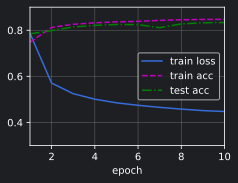

In [8]:
num_epochs = 10
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

## **Summary**
* By using the high-level APIs of deep learning frameworks, we can implement softmax regression more concisely.
* From a computational standpoint, implementing softmax regression is quite complex. In many cases, deep learning frameworks take additional precautions beyond these well-known techniques to ensure numerical stability. This helps us avoid the pitfalls we might encounter when writing models from scratch in practice.